# ADRMiner — Kruchten Taxonomy Classification

## Purpose

This notebook implements the **Kruchten taxonomy classification** stage of ADRMiner. It
compares three prompting strategies on a manually annotated ADR sample and then applies
the best-performing configuration to the complete curated corpus.

The four classification categories are:

- **Existence**
- **Ban / Non-existence**
- **Property**
- **Executive**

The notebook supports the taxonomy-based analyses reported for **RQ2** in the companion
paper, *“A Text Mining and Classification Approach for Analyzing Architecture Decision
Records.”*

## Prompting strategies

1. **Zero-shot:** taxonomy definitions and instructions only.
2. **Static few-shot:** the same labeled examples are included for every ADR.
3. **Dynamic few-shot:** examples are selected according to their similarity to the
   input ADR.

## Supported LLM providers

The notebook can use:

- **OpenAI**, through the standard OpenAI API; or
- **Ollama**, through Ollama's OpenAI-compatible endpoint.

Both options use LangChain's `ChatOpenAI` interface, allowing the rest of the
classification code to remain unchanged.

## Main inputs

- Curated ADR corpus under `../data/`.
- Manually annotated Kruchten sample under `../sample/`.
- Dynamic few-shot examples under `../sample/`.
- Provider configuration in a local `.env` file.

## Main outputs

- Ground-truth evaluation files for each prompting strategy.
- Classification metrics, confusion matrices, and disagreement analyses.
- Full-corpus predictions under `../results/`.

## Important execution notes

- New classification runs require a configured LLM provider and may take substantial
  time.
- OpenAI execution may incur API costs.
- Ollama requires a running server and a model with reliable instruction-following and
  structured-output capabilities.
- Keep `FORCE_RECOMPUTE = False` to reuse cached results.
- Run the notebook from the `notebooks/` directory so that relative paths resolve
  correctly.

## 1. Imports

The following cell imports the data-processing, visualization, evaluation, LangChain,
and ADRMiner modules used throughout the notebook.

In [1]:
import json
import logging
import os
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display, Markdown
from langchain_openai import ChatOpenAI
from tqdm import tqdm

from adr import adr
import utils
from adr_classification import (
    ADRClassifier,
    ClassificationFramework,
    KruchtenEnum,
)


---

## 2. Configuration

The configuration cell defines:

- the selected LLM provider and model;
- the input and output paths;
- the result-cache policy;
- parallel execution;
- the number of dynamic few-shot examples; and
- the example ADR used for prompt inspection.

### OpenAI `.env` configuration

```text
LLM_PROVIDER=openai
OPENAI_API_KEY=your-api-key
OPENAI_MODEL_NAME=gpt-4.1-mini
```

### Ollama `.env` configuration

For a local execution, first start Ollama and pull the desired model:

```bash
ollama serve
ollama pull qwen3:8b
```

Then configure the local `.env` file:

```text
LLM_PROVIDER=ollama
OLLAMA_MODEL_NAME=qwen3:8b
OLLAMA_BASE_URL=http://localhost:11434/v1
```

A local Ollama server does not require authentication. `ChatOpenAI` nevertheless expects
an API-key value, so the notebook supplies the placeholder `ollama`, which the local
server ignores.

### Result caching

- `FORCE_RECOMPUTE = False` loads existing JSON results when available.
- `FORCE_RECOMPUTE = True` reruns classification and overwrites the corresponding files.

Alternative provider/model outputs receive a suffix so they do not overwrite the
archived paper results.


In [2]:
# ------------------------------------------------------------------
# General execution settings
# ------------------------------------------------------------------

FORCE_RECOMPUTE = False
RUN_LLM_SMOKE_TEST = False
DYNAMIC_FEW_SHOT_K = 7
EXAMPLE_ADR_INDEX = 8

# Example project used only for optional demonstrations.
EXAMPLE_ORGANIZATION = 'LBHackney-IT'
EXAMPLE_PROJECT = 'remultiform'

In [3]:
# ------------------------------------------------------------------
# Input files
# ------------------------------------------------------------------

DATASET_PATH = Path('../data/LLM4ADR-adrs__adrs_english.pickle')
GROUND_TRUTH_PATH = Path('../sample/kruchten_gt_processed1_checked1.csv')
FEW_SHOTS_PATH = Path('../sample/krutchen_fewshots_raw.json')

# Base path for the complete-corpus predictions.
FULL_RESULTS_BASE = Path(
    '../results/all_projects-krutchen_classification_results.json'
)

In [4]:
# ------------------------------------------------------------------
# LLM provider configuration
# ------------------------------------------------------------------

load_dotenv()

LLM_PROVIDER = os.getenv('LLM_PROVIDER', 'openai').strip().lower()

if LLM_PROVIDER == 'openai':
    LLM_MODEL_NAME = os.getenv('OPENAI_MODEL_NAME')
    LLM_API_KEY = os.getenv('OPENAI_API_KEY')
    LLM_BASE_URL = None

    missing_variables = [
        name
        for name, value in {
            'OPENAI_API_KEY': LLM_API_KEY,
            'OPENAI_MODEL_NAME': LLM_MODEL_NAME,
        }.items()
        if not value
    ]
    if missing_variables:
        raise EnvironmentError(
            'Missing required OpenAI variable(s): '
            + ', '.join(missing_variables)
            + '. Configure them in .env or Colab Secrets.'
        )

elif LLM_PROVIDER == 'ollama':
    LLM_MODEL_NAME = os.getenv('OLLAMA_MODEL_NAME')
    LLM_BASE_URL = os.getenv(
        'OLLAMA_BASE_URL',
        'http://localhost:11434/v1',
    ).rstrip('/')

    # Required by ChatOpenAI but ignored by a local Ollama server.
    LLM_API_KEY = os.getenv('OLLAMA_API_KEY', 'ollama')

    if not LLM_MODEL_NAME:
        raise EnvironmentError(
            'OLLAMA_MODEL_NAME is not configured. Add a model name to .env, '
            'for example OLLAMA_MODEL_NAME=qwen3:8b.'
        )

else:
    raise ValueError(
        f"Unsupported LLM_PROVIDER={LLM_PROVIDER!r}. "
        "Use 'openai' or 'ollama'."
    )

# Local Ollama models are usually safer with sequential requests.
parallel_override = os.getenv('PARALLEL_CLASSIFICATION')
if parallel_override is None:
    PARALLEL_CLASSIFICATION = LLM_PROVIDER == 'openai'
else:
    PARALLEL_CLASSIFICATION = (
        parallel_override.strip().lower() in {'1', 'true', 'yes'}
    )

In [5]:
def slugify(value: str) -> str:
    """Convert a provider/model name into a filename-safe suffix."""
    return re.sub(r'[^a-zA-Z0-9._-]+', '-', value).strip('-').lower()

# Keep archived paper filenames unchanged for the default OpenAI configuration.
# Ollama outputs receive a provider/model suffix by default.
default_suffix = (
    ''
    if LLM_PROVIDER == 'openai'
    else f"-ollama-{slugify(LLM_MODEL_NAME)}"
)
RESULTS_SUFFIX = os.getenv('RESULTS_SUFFIX', default_suffix)

def with_results_suffix(path: Path) -> Path:
    """Append the experiment suffix before a file extension."""
    if not RESULTS_SUFFIX:
        return path
    return path.with_name(f'{path.stem}{RESULTS_SUFFIX}{path.suffix}')

ZERO_SHOT_RESULTS = with_results_suffix(
    GROUND_TRUTH_PATH.with_name(
        GROUND_TRUTH_PATH.stem + '_zero_shot_results.json'
    )
)
STATIC_FEW_SHOT_RESULTS = with_results_suffix(
    GROUND_TRUTH_PATH.with_name(
        GROUND_TRUTH_PATH.stem + '_static_few_shot_results.json'
    )
)
DYNAMIC_FEW_SHOT_RESULTS = with_results_suffix(
    GROUND_TRUTH_PATH.with_name(
        GROUND_TRUTH_PATH.stem + '_dynamic_few_shot_results.json'
    )
)
FULL_RESULTS_PATH = with_results_suffix(FULL_RESULTS_BASE)


In [6]:
print('LLM provider:', LLM_PROVIDER)
print('LLM model:', LLM_MODEL_NAME)
print('LLM base URL:', LLM_BASE_URL or 'OpenAI default')
print('Parallel classification:', PARALLEL_CLASSIFICATION)
print('Force recomputation:', FORCE_RECOMPUTE)
print('Result suffix:', RESULTS_SUFFIX or '(none)')

LLM provider: openai
LLM model: gpt-4.1-nano
LLM base URL: OpenAI default
Parallel classification: True
Force recomputation: False
Result suffix: (none)


In [7]:
print('Dataset:', DATASET_PATH)
print('Ground truth:', GROUND_TRUTH_PATH)
print('Few-shot examples:', FEW_SHOTS_PATH)
print('Full-corpus output:', FULL_RESULTS_PATH)


Dataset: ..\data\LLM4ADR-adrs__adrs_english.pickle
Ground truth: ..\sample\kruchten_gt_processed1_checked1.csv
Few-shot examples: ..\sample\krutchen_fewshots_raw.json
Full-corpus output: ..\results\all_projects-krutchen_classification_results.json


---

## 3. Initialize the language model

The following cell creates one `ChatOpenAI`-compatible client for the selected provider.
For Ollama, the client is redirected to the configured OpenAI-compatible `/v1`
endpoint. Temperature is set to zero to reduce output variability.

In [8]:
# Create one ChatOpenAI-compatible client for either provider.
llm_kwargs = {
    'model': LLM_MODEL_NAME,
    'api_key': LLM_API_KEY,
    'temperature': 0.0,
}

if LLM_BASE_URL:
    llm_kwargs['base_url'] = LLM_BASE_URL

llm = ChatOpenAI(**llm_kwargs)

print(
    f"Initialized {LLM_PROVIDER} model {LLM_MODEL_NAME!r}"
    + (f" at {LLM_BASE_URL}" if LLM_BASE_URL else "")
)


Initialized openai model 'gpt-4.1-nano'


### 3.1 Optional connectivity test

Enable the smoke test to verify that the configured provider and model are reachable
before starting classification. The test makes one model call.

In [9]:
if RUN_LLM_SMOKE_TEST:
    try:
        response = llm.invoke('Reply with exactly the word READY.')
        print('Provider response:', response.content)
    except Exception as exc:
        raise RuntimeError(
            f'Unable to invoke {LLM_PROVIDER}/{LLM_MODEL_NAME}. '
            'Check the model name, credentials, base URL, and provider service.'
        ) from exc
else:
    print('LLM smoke test skipped.')


LLM smoke test skipped.


## 4. Load and filter the ADR corpus

The curated dataset is organized by organization, project, and ADR. The notebook
reproduces the study's inclusion criteria by retaining projects with at least five ADRs
and an average ADR length of at least 500 characters.

In [10]:
with DATASET_PATH.open('rb') as file:
    dict_adrs = pickle.load(file)

print(len(dict_adrs), 'top-level organizations/projects loaded')

projects_dict = utils.process_projects(
    dict_adrs,
    min_adrs_per_project=5,
    min_adr_length=500,
)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(
    valid_projects,
    dict_adrs,
    field='raw',
)

print(len(valid_projects), 'valid organization/project pairs')
print(len(docs), 'ADRs considered within valid projects')


547 top-level organizations/projects loaded


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

312 valid organization/project pairs
4316 ADRs considered within valid projects


In [11]:
# Optional example project for interactive classification experiments.
adrs_to_classify = utils.get_documents_by_key(
    (EXAMPLE_ORGANIZATION, EXAMPLE_PROJECT),
    dict_adrs,
    field='raw',
)

print(
    len(adrs_to_classify),
    f"ADRs loaded for {EXAMPLE_ORGANIZATION}/{EXAMPLE_PROJECT}",
)


10 ADRs loaded for LBHackney-IT/remultiform


---

## 5. Load the manually annotated sample

The manually annotated subset is used to compare human labels with model predictions
under the three prompting strategies. It also supplies the ADR texts used for batch
evaluation.

## Kruchten's taxonomy

In [12]:
# Load the manually annotated Kruchten sample.
df_gt = pd.read_csv(
    GROUND_TRUTH_PATH,
    sep=';',
).dropna(
    subset=['text', 'human', 'ADR', 'raw_text']
)

print('Ground-truth shape:', df_gt.shape)
print(
    'Human categories:',
    len(df_gt['human'].unique()),
    df_gt['human'].unique(),
)
print(
    'Existing model categories:',
    len(df_gt['primary_category'].unique()),
    df_gt['primary_category'].unique(),
)

# Map ADR identifiers to their original text for batch classification.
adr_texts = {
    row['ADR']: row['raw_text']
    for _, row in df_gt.iterrows()
}
df_gt.head()


Ground-truth shape: (200, 10)
Human categories: 4 ['Existence (ontocrisis)' 'Executive (pericrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']
Existing model categories: 4 ['Existence (ontocrisis)' 'Property (diacrisis)' 'Executive (pericrisis)'
 'Ban/Non-Existence (anticrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,human_old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Executive (pericrisis),Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),Executive (pericrisis),1.0,# Cutting release branch does not create a set...


### 5.1 Cached evaluation helper

The helper below either loads an existing result file or reruns the selected prompting
strategy. This centralizes the cache and overwrite logic shared by all three evaluations.

In [13]:
def classify_or_load_ground_truth(
    classifier,
    output_path: Path,
    strategy_name: str,
):
    """Run one prompting strategy or load its cached predictions."""
    file_exists = output_path.is_file()
    should_recompute = FORCE_RECOMPUTE or not file_exists

    if should_recompute:
        if FORCE_RECOMPUTE and file_exists:
            print(
                f'FORCE_RECOMPUTE is enabled; cached {strategy_name} '
                'results will be overwritten.'
            )

        print(
            f'Evaluating {strategy_name} on '
            f'{len(adr_texts)} annotated ADRs.'
        )

        logging.getLogger(
            'adr_classification'
        ).setLevel(level=logging.CRITICAL)

        strategy_results = classifier.classify_batch(
            adr_texts,
            as_dict=True,
            parallel=PARALLEL_CLASSIFICATION,
        )

        print('Saving results to', output_path)
        classifier.save_results(
            strategy_results,
            str(output_path),
        )

        logging.getLogger(
            'adr_classification'
        ).setLevel(level=logging.INFO)

    else:
        with output_path.open('r', encoding='utf-8') as file:
            strategy_results = json.load(file)

        print(
            f'Loaded cached {strategy_name} results from {output_path}. '
            'Set FORCE_RECOMPUTE=True to regenerate them.'
        )

    return strategy_results


## 6. Kruchten taxonomy and example ADR

The following cells inspect the available categories and select one ADR from the
ground-truth sample for prompt and prediction demonstrations.

In [14]:
# Inspect the four labels defined by the Kruchten enumeration.
labels = sorted(str(member.value) for member in KruchtenEnum)
print(len(labels), labels)


4 ['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Existence (ontocrisis)', 'Property (diacrisis)']


In [15]:
# Select one annotated ADR for prompt and single-prediction demonstrations.
if EXAMPLE_ADR_INDEX >= len(df_gt):
    raise IndexError(
        f'EXAMPLE_ADR_INDEX={EXAMPLE_ADR_INDEX} is out of range for '
        f'{len(df_gt)} annotated ADRs.'
    )

adr_example = df_gt['raw_text'].tolist()[EXAMPLE_ADR_INDEX]
display(Markdown(adr_example))


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

## 7. Zero-shot strategy

The zero-shot prompt includes the taxonomy definitions and classification instructions,
but no labeled examples.

In [16]:
# Zero-shot classifier: taxonomy definitions and instructions only.
classifier = ADRClassifier(llm)
classifier.set_framework(
    ClassificationFramework.KRUCHTEN,
    include_examples=False,
)


{"asctime": "2026-06-20 16:57:46,939", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=False"}


In [17]:
# Inspect the complete zero-shot prompt instantiated for the example ADR.
print(classifier.classification_prompt.format(adr=adr_example))


System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines and rules provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
- **Ban/Non-Existence (anticrisis)**: This decision declares that an *element will not exist* in the de

In [18]:
# Run one zero-shot prediction.
result = classifier.classify(str(adr_example))
print(json.dumps(result, indent=4))


{"asctime": "2026-06-20 16:57:47,054", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}



**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like Rea

null


In [19]:
# Evaluate the zero-shot strategy on the annotated sample.
results = classify_or_load_ground_truth(
    classifier=classifier,
    output_path=ZERO_SHOT_RESULTS,
    strategy_name='zero-shot',
)


Loaded cached zero-shot results from ..\sample\kruchten_gt_processed1_checked1_zero_shot_results.json. Set FORCE_RECOMPUTE=True to regenerate them.


In [20]:
# Compare predictions with the human annotations.
output_dict = classifier.evaluate_on_ground_truth(
    df_gt,
    results,
    max_labels=4,
)


### Evaluation outputs

For each strategy, the notebook reports:

- label coverage;
- Matthews correlation coefficient;
- agreement with the human annotations;
- Cohen's kappa;
- class frequencies;
- classification report;
- normalized confusion matrix; and
- ADRs whose predicted label differs from the human label.

In [21]:
print(output_dict['labels'])
print()
print('Matthews coefficient:', output_dict['matthews'])
print('Agreement with ground truth (%):', output_dict['similarities'])
print('Cohen kappa with ground truth:', output_dict['kappa'])
output_dict['kappa_scores']


['Ban/Non-Existence (anticrisis)', 'Existence (ontocrisis)', 'Executive (pericrisis)', 'Property (diacrisis)']

Matthews coefficient: 0.20333991628181894
Agreement with ground truth (%): 61.5
Cohen kappa with ground truth: 0.18241664897005716


{'Ban/Non-Existence (anticrisis)': 0.24863387978142082,
 'Executive (pericrisis)': 0.09170305676855894,
 'Existence (ontocrisis)': 0.27122555569051376,
 'Property (diacrisis)': 0.09197422378441711}

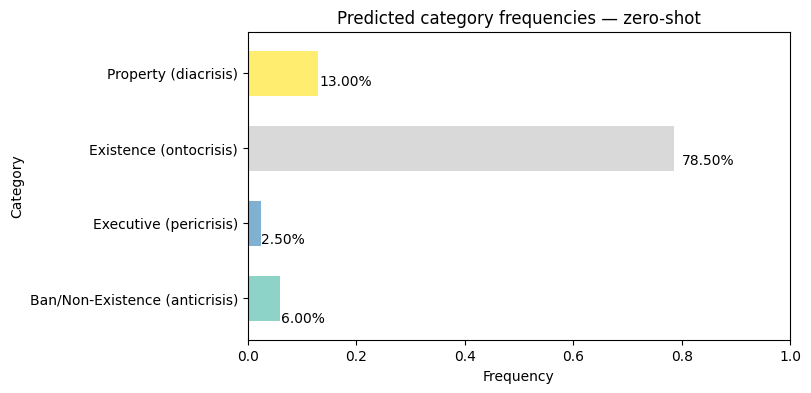

In [22]:
target_values = [
    result['primary_category']
    for result in results
]

title = 'Predicted category frequencies — zero-shot'
my_colors = utils.show_target_frequencies(
    pd.Series(target_values),
    title=title,
)


In [23]:
my_colors

{'Ban/Non-Existence (anticrisis)': '#8dd3c7',
 'Executive (pericrisis)': '#80b1d3',
 'Existence (ontocrisis)': '#d9d9d9',
 'Property (diacrisis)': '#ffed6f'}

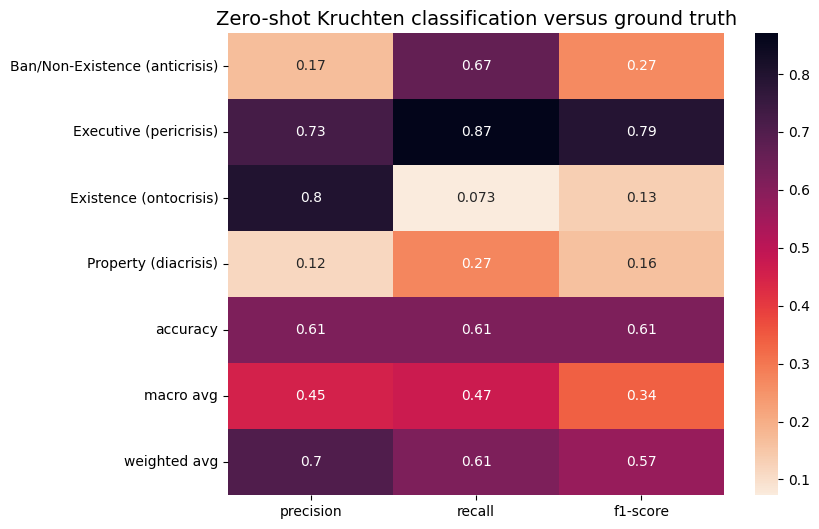

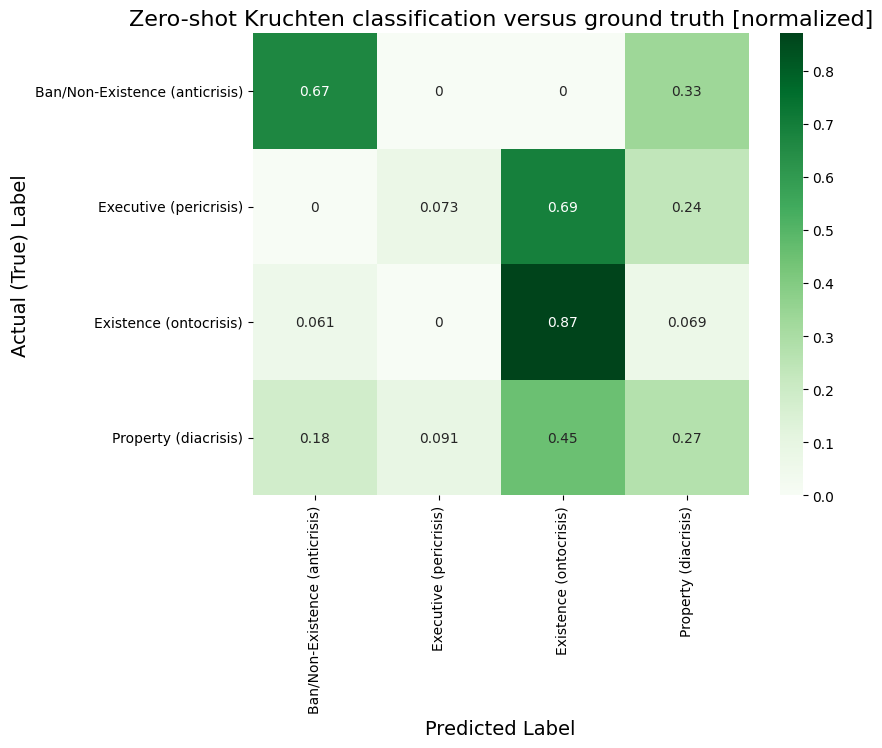

In [24]:
title = "Zero-shot Kruchten classification versus ground truth"
utils.show_classification_report(
    output_dict['report'],
    title=title,
)
utils.show_confusion_matrix(
    output_dict['confusion_matrix'],
    title=title,
    normalized=True,
)


All colors: 64 classes: 4 mosaic tuples: 16


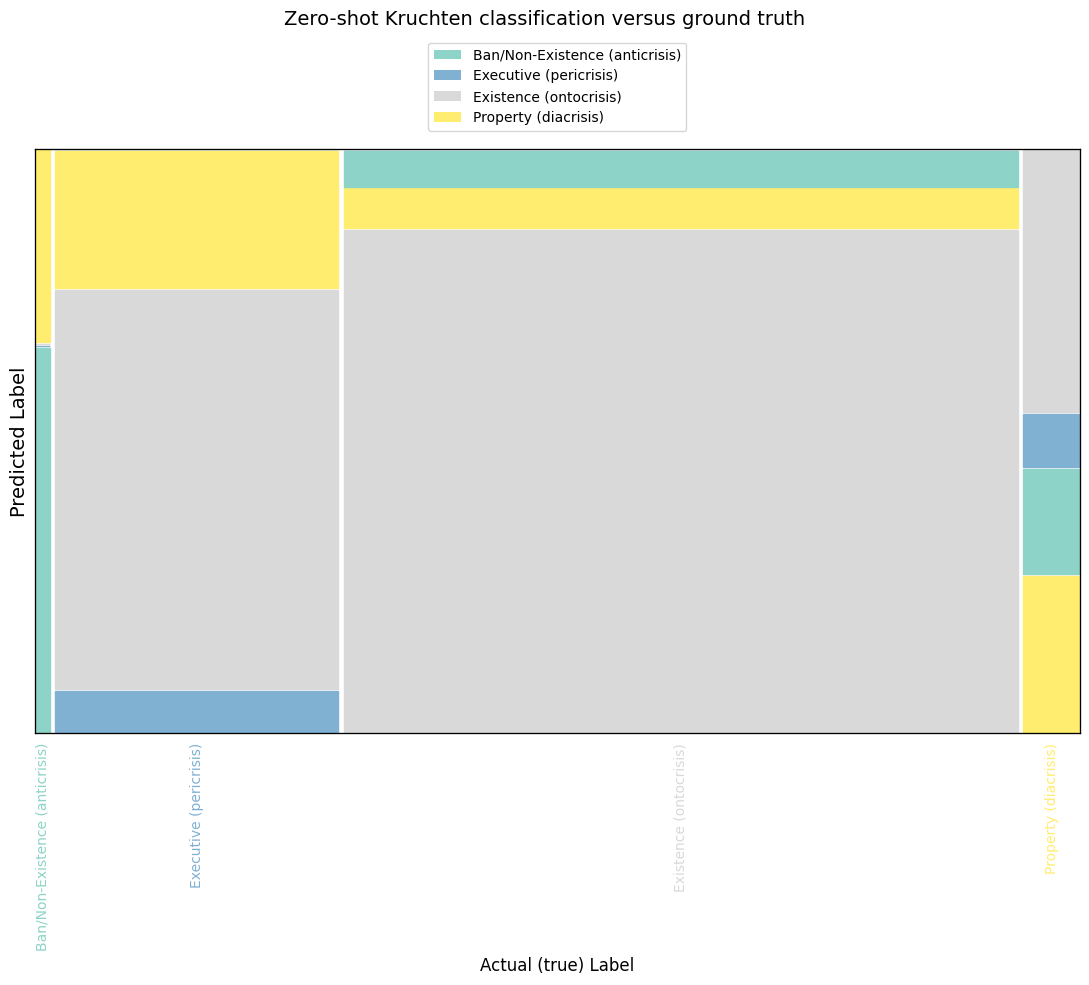

In [25]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(
    output_dict['confusion_matrix'].values,
    cm_labels=cm_labels,
    color_dict=my_colors,
    title=title,
)


In [26]:
print('Differences with ground truth:', len(output_dict['differences']))
ADRClassifier.rank_differences(
    output_dict['differences'],
    n_categories=4,
)


Differences with ground truth: 77


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 38),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 13),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 9),
 (('Existence (ontocrisis)', 'Ban/Non-Existence (anticrisis)'), 8)]

## 8. Static few-shot strategy

The static few-shot prompt adds the same representative examples for every ADR.

### Static few-shot strategy

In [27]:
# Static few-shot classifier: the same examples are used for every ADR.
classifier = ADRClassifier(llm)
classifier.set_framework(
    ClassificationFramework.KRUCHTEN,
    include_examples=True,
)


{"asctime": "2026-06-20 16:57:47,708", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


INFO:adr_classification:Using classification framework: kruchten, include_examples=True


In [28]:
# Inspect the complete static few-shot prompt for the example ADR.
print(classifier.classification_prompt.format(adr=adr_example))


System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines, rules and examples provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
Examples:
    + ✅ "We will use PostgreSQL as our primary database"
    + ✅ "Implement an API 

In [29]:
# Run one static few-shot prediction.
result = classifier.classify(str(adr_example))
print(json.dumps(result, indent=4))


{"asctime": "2026-06-20 16:57:47,727", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}


INFO:adr_classification:Classifying ADR with 392 tokens.

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps

null


In [30]:
# Evaluate the static few-shot strategy on the annotated sample.
results = classify_or_load_ground_truth(
    classifier=classifier,
    output_path=STATIC_FEW_SHOT_RESULTS,
    strategy_name='static few-shot',
)


Loaded cached static few-shot results from ..\sample\kruchten_gt_processed1_checked1_static_few_shot_results.json. Set FORCE_RECOMPUTE=True to regenerate them.


In [31]:
output_dict = classifier.evaluate_on_ground_truth(
    df_gt,
    results,
    max_labels=4,
)


In [32]:
print(output_dict['labels'])
print()
print('Matthews coefficient:', output_dict['matthews'])
print('Agreement with ground truth (%):', output_dict['similarities'])
print('Cohen kappa with ground truth:', output_dict['kappa'])
output_dict['kappa_scores']


['Ban/Non-Existence (anticrisis)', 'Existence (ontocrisis)', 'Executive (pericrisis)', 'Property (diacrisis)']

Matthews coefficient: 0.26976972537544835
Agreement with ground truth (%): 63.0
Cohen kappa with ground truth: 0.25086049807653377


{'Ban/Non-Existence (anticrisis)': 0.2913385826771653,
 'Executive (pericrisis)': 0.19933277731442878,
 'Existence (ontocrisis)': 0.3444925670139296,
 'Property (diacrisis)': 0.11347517730496448}

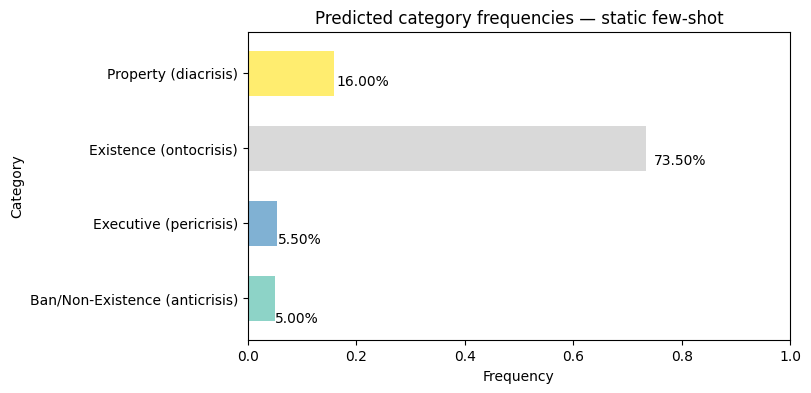

In [33]:
target_values = [
    result['primary_category']
    for result in results
]

title = 'Predicted category frequencies — static few-shot'
my_colors = utils.show_target_frequencies(
    pd.Series(target_values),
    title=title,
)


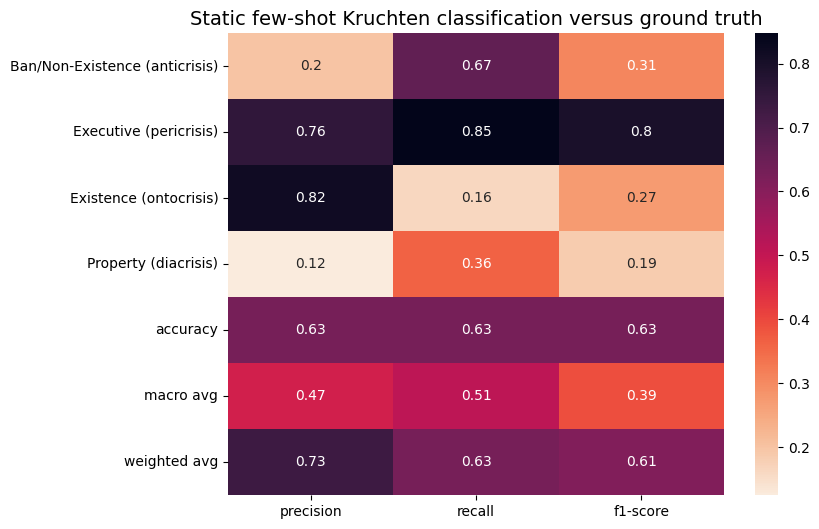

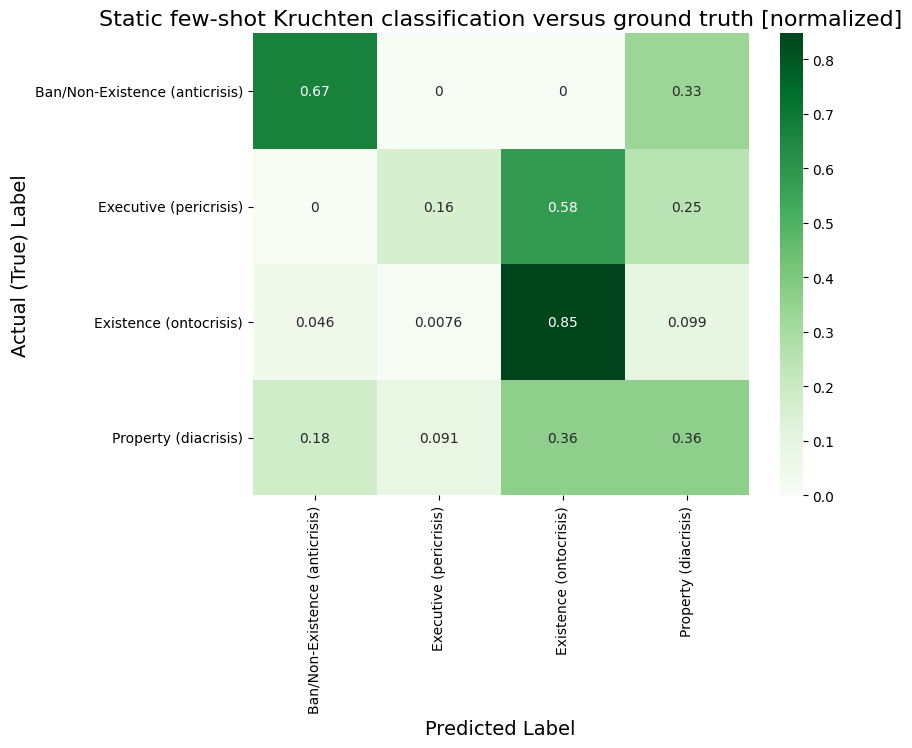

In [34]:
title = "Static few-shot Kruchten classification versus ground truth"
utils.show_classification_report(
    output_dict['report'],
    title=title,
)
utils.show_confusion_matrix(
    output_dict['confusion_matrix'],
    title=title,
    normalized=True,
)


All colors: 64 classes: 4 mosaic tuples: 16


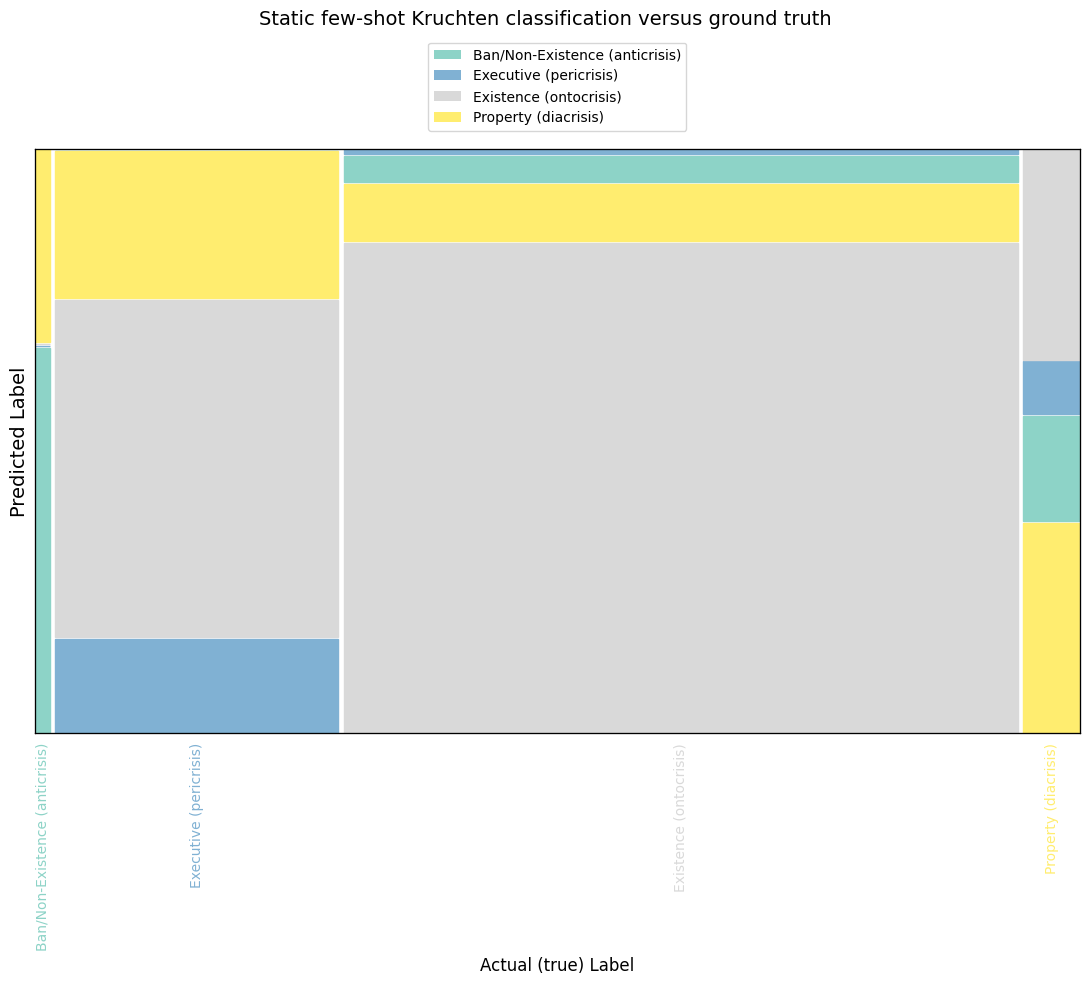

In [35]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(
    output_dict['confusion_matrix'].values,
    cm_labels=cm_labels,
    color_dict=my_colors,
    title=title,
)


In [36]:
print('Differences with ground truth:', len(output_dict['differences']))
ADRClassifier.rank_differences(
    output_dict['differences'],
    n_categories=4,
)


Differences with ground truth: 74


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 32),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 14),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 13),
 (('Existence (ontocrisis)', 'Ban/Non-Existence (anticrisis)'), 6)]

## 9. Dynamic few-shot strategy

The dynamic strategy loads a larger example pool and selects the `DYNAMIC_FEW_SHOT_K`
most relevant examples for each input ADR.

### Dynamic few-shot strategy

In [37]:
# Load the example pool used by dynamic few-shot selection.
with FEW_SHOTS_PATH.open('r', encoding='utf-8') as file:
    adr_examples = json.load(file)

print(len(adr_examples), 'few-shot examples loaded')


200 few-shot examples loaded


In [38]:
# Dynamic few-shot classifier: select the most relevant examples per ADR.
classifier = ADRClassifier(llm)
classifier.set_framework(
    ClassificationFramework.KRUCHTEN,
    include_examples=True,
    examples=adr_examples,
    k=DYNAMIC_FEW_SHOT_K,
)


{"asctime": "2026-06-20 16:57:48,266", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


INFO:adr_classification:Using classification framework: kruchten, include_examples=True


In [39]:
# Inspect the dynamic few-shot prompt instantiated for the example ADR.
print(classifier.classification_prompt.format(adr=adr_example))


Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines and rules provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
- **Ban/Non-Existence (anticrisis)**: This decision declares that an *element will not exist* in the design or 

In [40]:
# Run one dynamic few-shot prediction.
result = classifier.classify(str(adr_example))
print(json.dumps(result, indent=4))


{"asctime": "2026-06-20 16:57:56,062", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}


INFO:adr_classification:Classifying ADR with 392 tokens.

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage\.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given\. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss\.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use\. This means that the app will be accessible offline\. This option would also allow us to create a single application which could be used on any device with a modern web browser\.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows)\. The

null


In [41]:
# Evaluate the dynamic few-shot strategy on the annotated sample.
results = classify_or_load_ground_truth(
    classifier=classifier,
    output_path=DYNAMIC_FEW_SHOT_RESULTS,
    strategy_name='dynamic few-shot',
)


Loaded cached dynamic few-shot results from ..\sample\kruchten_gt_processed1_checked1_dynamic_few_shot_results.json. Set FORCE_RECOMPUTE=True to regenerate them.


In [42]:
output_dict = classifier.evaluate_on_ground_truth(
    df_gt,
    results,
    max_labels=4,
)


{"asctime": "2026-06-20 16:57:57,401", "levelname": "WARNING", "name": "adr_classification", "message": "Dropping 4 as they are not part of the LLM results. ['0016-not-supporting-type-definitions.md', 'zindex-values.md', 'adr-067-mempool-refactor.md', '0002-use-bullet-to-catch-nplus1-queries.md']"}


In [43]:
print(output_dict['labels'])
print()
print('Matthews coefficient:', output_dict['matthews'])
print('Agreement with ground truth (%):', output_dict['similarities'])
print('Cohen kappa with ground truth:', output_dict['kappa'])
output_dict['kappa_scores']


['Ban/Non-Existence (anticrisis)', 'Existence (ontocrisis)', 'Executive (pericrisis)', 'Property (diacrisis)']

Matthews coefficient: 0.40461784599152417
Agreement with ground truth (%): 66.3265306122449
Cohen kappa with ground truth: 0.38781884435190006


{'Ban/Non-Existence (anticrisis)': 0.48825065274151436,
 'Executive (pericrisis)': 0.3799382716049383,
 'Existence (ontocrisis)': 0.43023255813953487,
 'Property (diacrisis)': 0.2904782799473453}

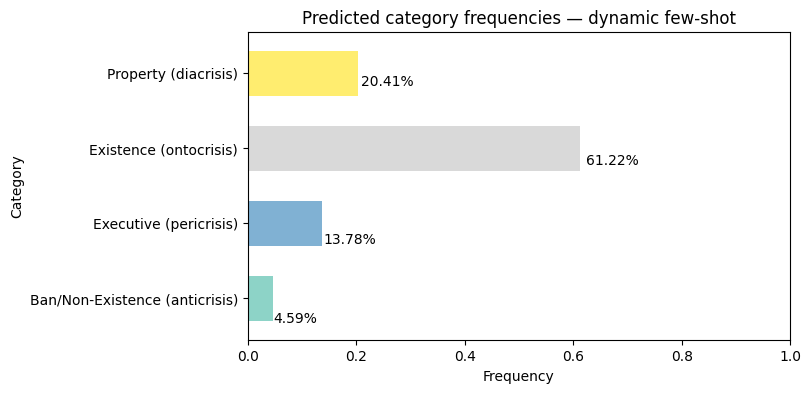

In [44]:
target_values = [
    result['primary_category']
    for result in results
]

title = 'Predicted category frequencies — dynamic few-shot'
my_colors = utils.show_target_frequencies(
    pd.Series(target_values),
    title=title,
)


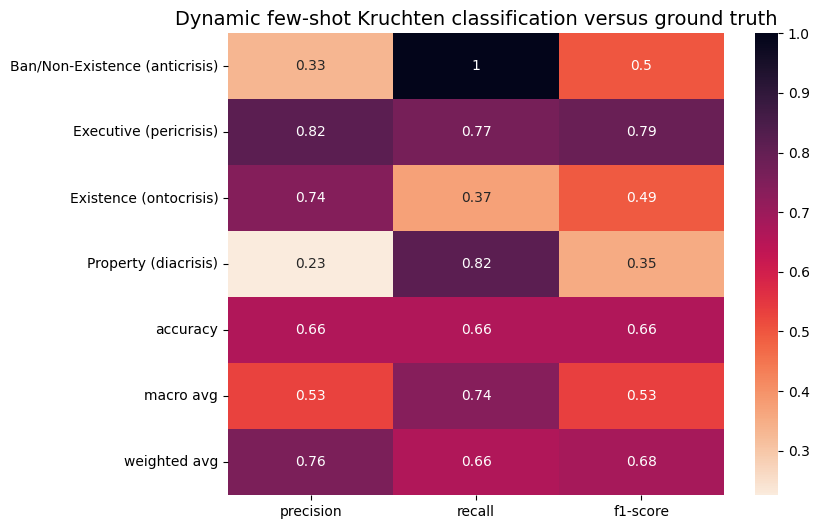

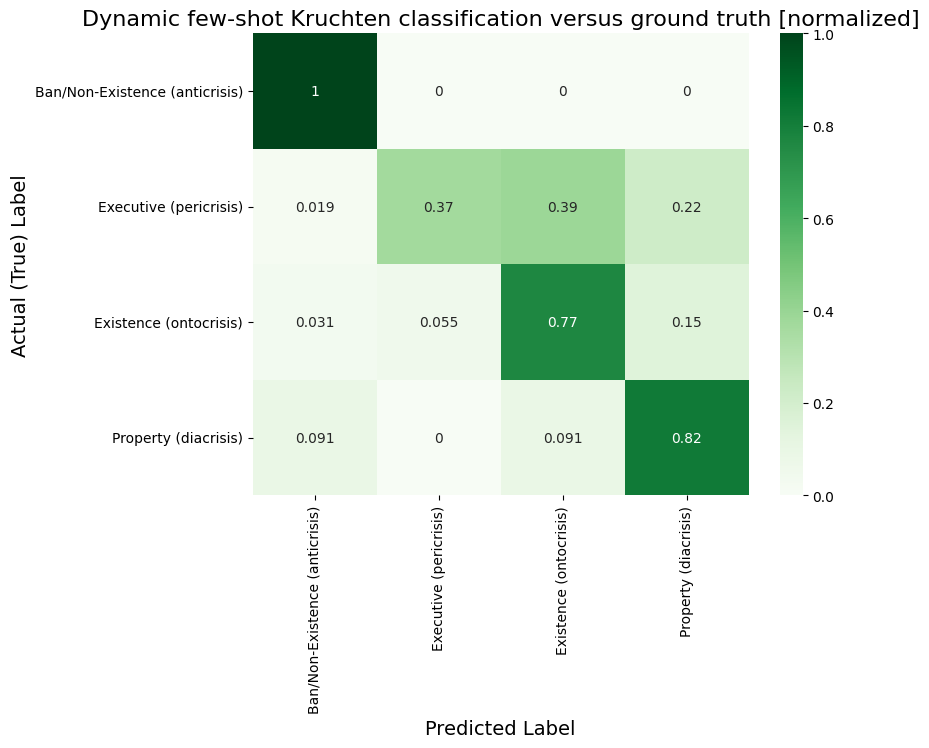

In [45]:
title = "Dynamic few-shot Kruchten classification versus ground truth"
utils.show_classification_report(
    output_dict['report'],
    title=title,
)
utils.show_confusion_matrix(
    output_dict['confusion_matrix'],
    title=title,
    normalized=True,
)


All colors: 64 classes: 4 mosaic tuples: 16


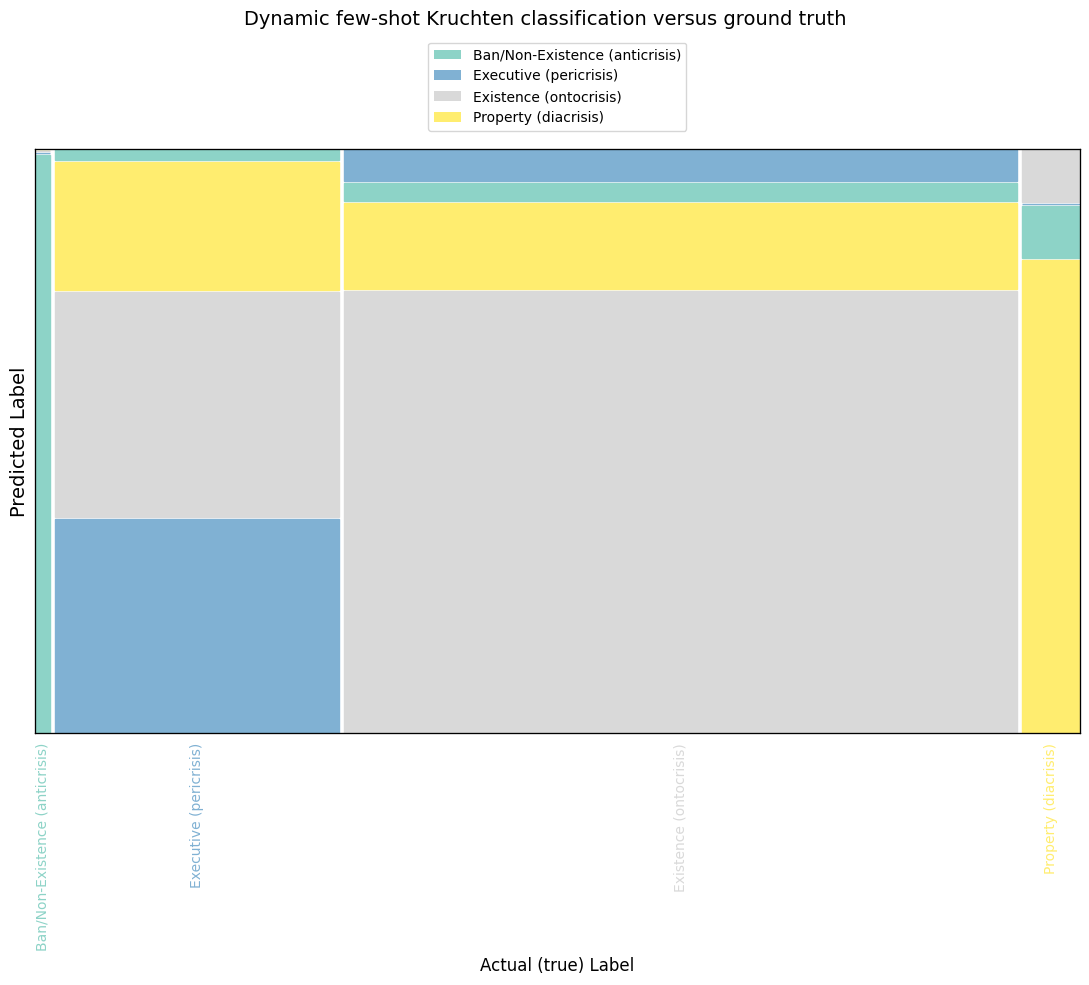

In [46]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(
    output_dict['confusion_matrix'].values,
    cm_labels=cm_labels,
    color_dict=my_colors,
    title=title,
)


In [47]:
print('Differences with ground truth:', len(output_dict['differences']))
ADRClassifier.rank_differences(
    output_dict['differences'],
    n_categories=4,
)


Differences with ground truth: 66


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 21),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 19),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 12),
 (('Existence (ontocrisis)', 'Executive (pericrisis)'), 7)]

---

## 10. Apply the selected strategy to the complete corpus

The companion study uses the dynamic few-shot configuration for Kruchten classification.
This stage applies it to all ADRs in the valid projects and stores the resulting JSON
file under `../results/`.

> **Runtime and cost warning:** Full-corpus classification requires thousands of model
> calls. Reuse the archived output unless a complete rerun is necessary.

In [48]:
# Final output path selected for this provider/model experiment.
print('Full-corpus results:', FULL_RESULTS_PATH)


Full-corpus results: ..\results\all_projects-krutchen_classification_results.json


In [49]:
# The companion study selected dynamic few-shot prompting for Kruchten.
best_classifier = ADRClassifier(llm)
best_classifier.set_framework(
    ClassificationFramework.KRUCHTEN,
    include_examples=True,
    examples=adr_examples,
    k=DYNAMIC_FEW_SHOT_K,
)


{"asctime": "2026-06-20 16:57:57,803", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


INFO:adr_classification:Using classification framework: kruchten, include_examples=True


In [50]:
# Apply the selected classifier to all valid projects or reuse cached results.
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

file_exists = FULL_RESULTS_PATH.is_file()
should_recompute = FORCE_RECOMPUTE or not file_exists

if should_recompute:
    if FORCE_RECOMPUTE and file_exists:
        print(
            'FORCE_RECOMPUTE is enabled; cached full-corpus results '
            'will be overwritten.'
        )

    print(
        f'Classifying ADRs from {len(valid_projects)} valid projects '
        f'using {LLM_PROVIDER}/{LLM_MODEL_NAME}.'
    )

    all_results = []

    for org, project in tqdm(
        valid_projects,
        desc='Processing organizations/projects',
    ):
        project_adrs = utils.get_documents_by_key(
            (org, project),
            dict_adrs,
            field='raw',
        )

        project_results = best_classifier.classify_batch(
            project_adrs,
            parallel=PARALLEL_CLASSIFICATION,
            project=project,
            organization=org,
            as_dict=True,
        )
        all_results.extend(project_results)

    print('Saving JSON results to', FULL_RESULTS_PATH)
    ADRClassifier.save_results(
        all_results,
        str(FULL_RESULTS_PATH),
    )

else:
    with FULL_RESULTS_PATH.open('r', encoding='utf-8') as file:
        all_results = json.load(file)

    print(
        'Loaded cached full-corpus results from',
        FULL_RESULTS_PATH,
        '\nSet FORCE_RECOMPUTE=True to regenerate them.',
    )

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
print('End.')


Loaded cached full-corpus results from ..\results\all_projects-krutchen_classification_results.json 
Set FORCE_RECOMPUTE=True to regenerate them.
End.


In [51]:
print(len(all_results), 'ADR classifications available.')


4213 ADR classifications available.


---

## 11. Expected artifacts and reuse

The notebook produces evaluation results for all three prompting strategies and a
full-corpus Kruchten classification file.

To compare another model or provider, keep the archived result files unchanged and use
the automatically generated experiment suffix. The downstream
`classification_analysis.ipynb` notebook can then be pointed to the alternative result
file.